# Hypothesis test 1

## import data 

In [178]:
library(lme4)
library(lmerTest)
library(dplyr)
library(emmeans)
library(car)
library(ggplot2)
library(tidyr)


Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack




In [168]:
fulldata = read.csv("/Users/emmal/Library/CloudStorage/OneDrive-Personal/Documents/Schule/Cambridge/PART II/PBS5/CODE/VisualSearchLLM/veo_results/mergedVeo3.csv", stringsAsFactors =T)
groupeddata = read.csv("/Users/emmal/Library/CloudStorage/OneDrive-Personal/Documents/Schule/Cambridge/PART II/PBS5/CODE/VisualSearchLLM/veo_results/generative_success.csv", stringsAsFactors = T)
fulldataAS = read.csv("/Users/emmal/Desktop/CODE/VisualSearchLLM/Analysis/AmbiguityAsSuccess.csv", stringsAsFactors = T)
groupeddataAS = read.csv("/Users/emmal/Desktop/CODE/VisualSearchLLM/Analysis/generative_success_AS.csv", stringsAsFactors = T)

In [169]:
fulldata = fulldata %>% filter(condition != "NoDistractors")
fulldata$bin_group = as.factor(fulldata$bin_group)
fulldata$condition <- droplevels(fulldata$condition)
table(fulldata$success)
table(fulldata$condition)
table(fulldata$bin_group)

fulldata$condtion = as.factor(fulldata$condition)
fulldata$bin_group = as.integer(fulldata$bin_group)
fulldata$video_filename = as.factor(fulldata$video_filename)
class(fulldata$bin_group)   


 0  1 
80 28 


  2Among5Colour  2Among5ConjRed 2Among5NoColour 
             36              36              36 


 1  2  3  4  5  6 
18 18 18 18 18 18 

[1] "integer"

## Assumption testing

, ,  = 1

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             1              1               2
  1             5              5               4

, ,  = 2

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             2              6               6
  1             4              0               0

, ,  = 3

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             4              5               5
  1             2              1               1

, ,  = 4

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             4              6               6
  1             2              0               0

, ,  = 5

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             5              6               6
  1             1              0               0

, ,  = 6

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             3              6               6
  1             3              0               0


Model :
success ~ condition * bin_group


there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



,GVIF,Df,GVIF^(1/(2*Df))
condition,33.422511,2,2.404417
bin_group,1.617035,1,1.271627
condition:bin_group,26.227688,2,2.263028


,GVIF,Df,GVIF^(1/(2*Df))
condition,1.179457,2,1.042127
bin_group,1.179457,1,1.086028


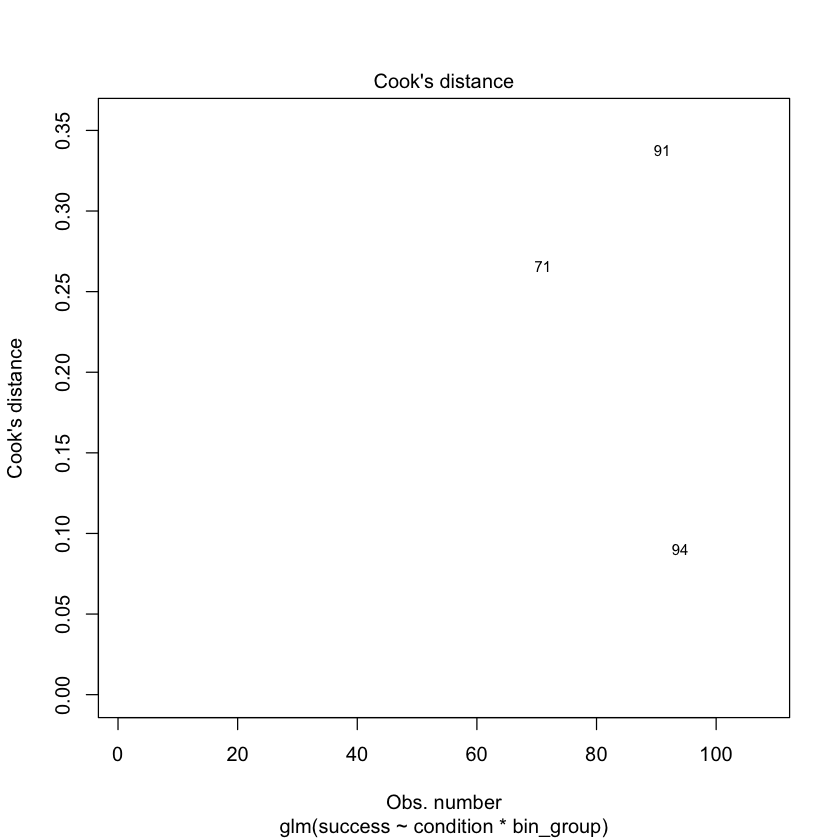

,StudRes,Hat,CookD
,<dbl>,<dbl>,<dbl>
71,2.7533225,0.06610700,0.25847710
75,0.8565307,0.14485672,0.01306034
90,0.8565307,0.14485672,0.01306034
91,2.8972654,0.06797507,0.33082150


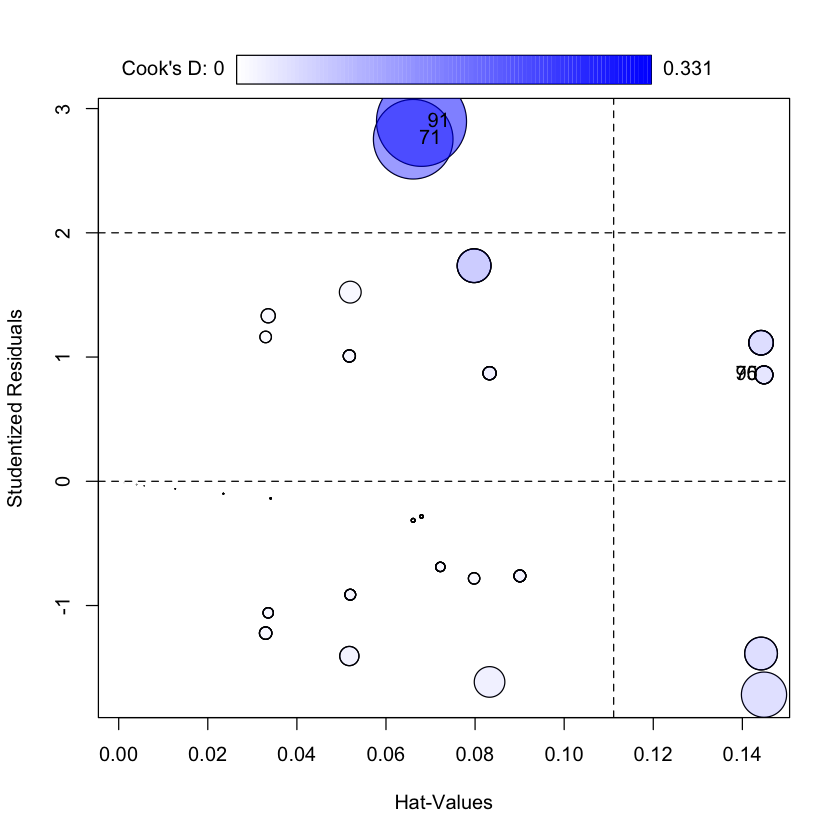

,StudRes,Hat,CookD
,<dbl>,<dbl>,<dbl>
5,2.184556,0.04002795,0.08870675
9,2.184556,0.04002795,0.08870675
38,-1.019514,0.07705825,0.01441476
47,-1.019514,0.07705825,0.01441476


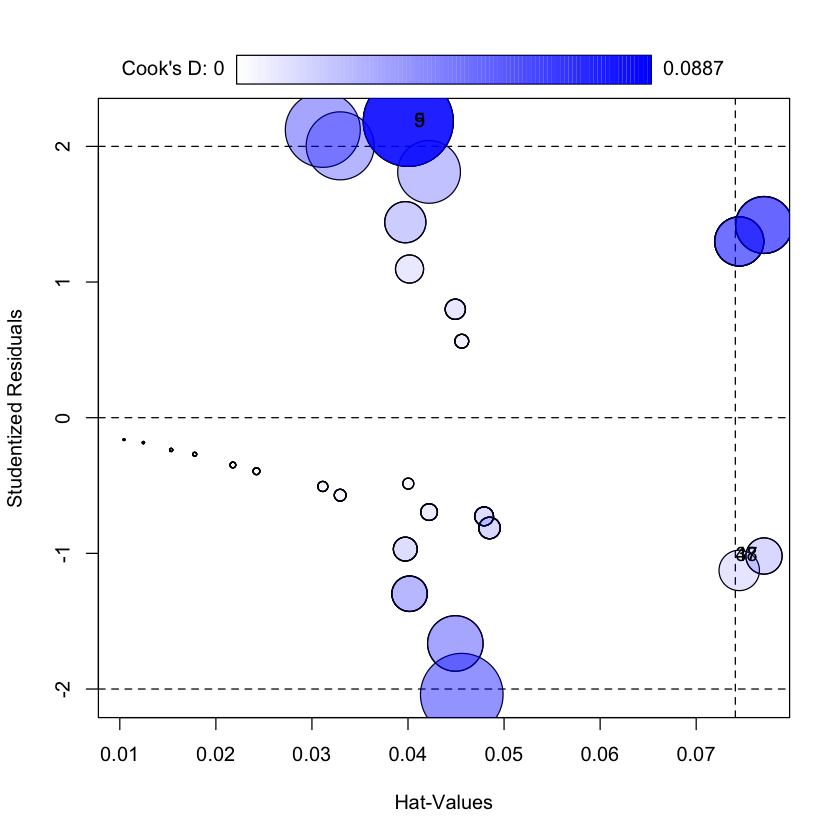

In [164]:
modelRQ1 = glm(success ~condition*bin_group, data = fulldata, family = binomial(link = "logit"))
smallmodelRQ1 = glm(success ~ condition + bin_group, data   = fulldata, family = binomial(link = "logit"))
# separation (OK)
table(fulldata$success, fulldata$condition, fulldata$bin_group)
# multicollinearity of IVs - < 10 (likley ok; GVIF for df= 1 ok, ADjusted GVIF^(1/2*df) < sqrt(threshold))
alias(modelRQ1)
car::vif(modelRQ1)
car::vif(smallmodelRQ1)
# linearity of log odds - only for continuous 
# DV is binominal
# uniqueness of observations (for now) assumed
# Sample size at least 10 per term = not given but cannot change (success = 28; fail = 80) <- given DF = 17 issue partially 
# outliers = cooks distance is OK
plot(modelRQ1, which = 4, col = "white")
influencePlot(modelRQ1, id=T)
influencePlot(smallmodelRQ1, id = T)

## Run model(S)

In [165]:
# drop1(modelRQ1, test = "Chisq")
summary(modelRQ1)
# drop1(smallmodelRQ1, test = "Chisq")
summary(smallmodelRQ1)
cat("\n  Odds ratios (exp(coef)):\n")
print(round(exp(cbind(OR = coef(modelRQ1), confint(modelRQ1))), 3))


Call:
glm(formula = success ~ condition * bin_group, family = binomial(link = "logit"), 
    data = fulldata)

Coefficients:
                                   Estimate Std. Error z value Pr(>|z|)  
(Intercept)                          1.2252     0.8148   1.504   0.1327  
condition2Among5ConjRed              1.7826     1.7846   0.999   0.3179  
condition2Among5NoColour             0.7181     1.6070   0.447   0.6550  
bin_group                           -0.3852     0.2138  -1.802   0.0715 .
condition2Among5ConjRed:bin_group   -1.6952     0.9164  -1.850   0.0643 .
condition2Among5NoColour:bin_group  -1.2687     0.7992  -1.587   0.1124  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 123.613  on 107  degrees of freedom
Residual deviance:  79.731  on 102  degrees of freedom
AIC: 91.731

Number of Fisher Scoring iterations: 7



Call:
glm(formula = success ~ condition + bin_group, family = binomial(link = "logit"), 
    data = fulldata)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)                2.5639     0.7664   3.346 0.000821 ***
condition2Among5ConjRed   -1.9814     0.6674  -2.969 0.002988 ** 
condition2Among5NoColour  -2.2370     0.6961  -3.214 0.001311 ** 
bin_group                 -0.7774     0.1935  -4.018 5.86e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 123.61  on 107  degrees of freedom
Residual deviance:  88.52  on 104  degrees of freedom
AIC: 96.52

Number of Fisher Scoring iterations: 5



  Odds ratios (exp(coef)):


Waiting for profiling to be done...



                                      OR 2.5 %  97.5 %
(Intercept)                        3.405 0.730  18.972
condition2Among5ConjRed            5.945 0.248 365.113
condition2Among5NoColour           2.051 0.104  68.863
bin_group                          0.680 0.433   1.015
condition2Among5ConjRed:bin_group  0.184 0.018   0.741
condition2Among5NoColour:bin_group 0.281 0.037   0.960


## post hock testing

In [166]:
# post-hoc tests for bin effects within each condition (Each row tests H₀: slope = 0)
trends_RQ1 <- emtrends(modelRQ1, 
                       specs = ~ condition, 
                       var   = "bin_group")
summary(trends_RQ1, infer = c(TRUE, TRUE))
# => set sixe effect in condition ?
# paiwise contrasts for slope diffrerences across conditions 
trends_RQ1_pairs <- emtrends(modelRQ1, pairwise ~ condition, var = "bin_group")
summary(trends_RQ1_pairs$contrasts, infer = c(TRUE, TRUE))
# => conditions differ in steepness of slope ? 
## results show no significant differences in slope across conditions, but a significant slope in the NOColour & Conjunctive condition (and non-significant slope in simple colour condition).

# Polynimical contrasts 
## by bin group trend structures across conditions - check for linear = specified post hock test of most interest! 
bin_RQ1_structure = emmeans(modelRQ1, specs = ~ condition | bin_group) %>%
  contrast("poly")
summary(bin_RQ1_structure, infer = c(TRUE, TRUE))
## RESULTS SHOW: sig. linear trend; non sig. quadrratic trend

,condition,bin_group.trend,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2Among5Colour,-0.3852178,0.2137720,Inf,-0.8042032,0.0337677,-1.802003,0.07154498
2,2Among5ConjRed,-2.0803919,0.8911169,Inf,-3.8269490,-0.3338348,-2.334589,0.01956489
3,2Among5NoColour,-1.6539462,0.7700982,Inf,-3.1633109,-0.1445815,-2.147708,0.03173695


,contrast,estimate,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2Among5Colour - 2Among5ConjRed,1.6951741,0.9163994,Inf,-0.4525917,3.842940,1.8498202,0.1535842
2,2Among5Colour - 2Among5NoColour,1.2687284,0.7992182,Inf,-0.6043997,3.141857,1.5874619,0.2510246
3,2Among5ConjRed - 2Among5NoColour,-0.4264457,1.1777693,Inf,-3.1867844,2.333893,-0.3620791,0.9302890


,contrast,bin_group,estimate,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,linear,3.5,-3.722432,1.605462,Inf,-6.86908,-0.575785,-2.318605,0.02041645
2,quadratic,3.5,4.578680,3.892010,Inf,-3.04952,12.206881,1.176431,0.23942286


# Hypothesis 2 

## import data 

In [159]:
humandata = read.csv("/Users/emmal/Desktop/CODE/VisualSearchLLM/Analysis/HumanData.csv", stringsAsFactors = T)
print(colnames(humandata))
table(humandata$shape_type)
table(humandata$target_color)
table(humandata$distractor_color)

 [1] "PID"              "trial"            "response"         "rt"              
 [5] "accuracy"         "display"          "filename"         "shape_type"      
 [9] "colour_type"      "target_color"     "distractor_color" "quadrant"        
[13] "num_distractors"  "answer"           "distractor_bin"   "bin_group"       



   2    5 
2160 2160 


 blue green   red 
 1440  1440  1440 


 blue green   red 
 1440  1440  1440 

### test for colour/ identity effects as of coundernbalancing = gaps 

In [ ]:
chisq.test(table(humandata$shape_type, humandata$accuracy))
chisq.test(table(humandata$target_color, humandata$accuracy))
chisq.test(table(humandata$distractor_color, humandata$accuracy))

# not significant target and shape effects, distractor may be confounded by search condition hence I choose to proceed with the full data set to omit issues with the missing data otherwise



	Pearson's Chi-squared test with Yates' continuity correction

data:  table(humandata$shape_type, humandata$accuracy)
X-squared = 0.18672, df = 1, p-value = 0.6657



	Pearson's Chi-squared test

data:  table(humandata$target_color, humandata$accuracy)
X-squared = 4.3024, df = 2, p-value = 0.1163



	Pearson's Chi-squared test

data:  table(humandata$distractor_color, humandata$accuracy)
X-squared = 22.041, df = 2, p-value = 1.636e-05


## descriptive

In [175]:
veo_success = read.csv("/Users/emmal/Desktop/CODE/VisualSearchLLM/Analysis/generative_success.csv", stringsAsFactors = T)
Veo_summary <- veo_success %>%
  rename(
    bin_group    = bin,
    mean_acc_veo = generative_success,
    se_veo       = std_success
  ) %>%
  mutate(
    condition = as.character(condition),
    bin_group = as.integer(bin_group)
  ) %>%
  select(condition, bin_group, mean_acc_veo, se_veo, ci_lower, ci_upper)

Human_summary <- humandata %>%
  group_by(colour_type, bin_group) %>%
  summarise(
    mean_acc_human = mean(accuracy, na.rm = TRUE),
    n              = n(),
    se_human       = sqrt(mean_acc_human * (1 - mean_acc_human) / n),
    .groups        = "drop"
  ) %>%
  rename(condition = colour_type) %>%
  mutate(
    condition = as.character(condition),
    bin_group = as.integer(bin_group)
  ) %>%
  select(condition, bin_group, mean_acc_human, se_human)

combined_wide <- Veo_summary %>%
  full_join(Human_summary, by = c("condition", "bin_group"))

print(head(combined_wide))

      condition bin_group mean_acc_veo    se_veo    ci_lower  ci_upper
1 2Among5Colour         1    0.8333333 0.4082483  0.53512883 1.1315378
2 2Among5Colour         2    0.6666667 0.5163978  0.28946449 1.0438688
3 2Among5Colour         3    0.3333333 0.5163978 -0.04386884 0.7105355
4 2Among5Colour         4    0.3333333 0.5163978 -0.04386884 0.7105355
5 2Among5Colour         5    0.1666667 0.4082483 -0.13153784 0.4648712
6 2Among5Colour         6    0.5000000 0.5477226  0.09991668 0.9000833
  mean_acc_human    se_human
1      0.9833333 0.008263597
2      0.9666667 0.011587030
3      0.9750000 0.010077822
4      0.9708333 0.010862008
5      0.9833333 0.008263597
6      1.0000000 0.000000000


### plotting

      condition bin_group    se_veo    ci_lower  ci_upper    se_human agent
1 2Among5Colour         1 0.4082483  0.53512883 1.1315378 0.008263597   Veo
2 2Among5Colour         2 0.5163978  0.28946449 1.0438688 0.011587030   Veo
3 2Among5Colour         3 0.5163978 -0.04386884 0.7105355 0.010077822   Veo
4 2Among5Colour         4 0.5163978 -0.04386884 0.7105355 0.010862008   Veo
5 2Among5Colour         5 0.4082483 -0.13153784 0.4648712 0.008263597   Veo
6 2Among5Colour         6 0.5477226  0.09991668 0.9000833 0.000000000   Veo
   mean_acc        se
1 0.8333333 0.4082483
2 0.6666667 0.5163978
3 0.3333333 0.5163978
4 0.3333333 0.5163978
5 0.1666667 0.4082483
6 0.5000000 0.5477226

Human   Veo 
   19    19 


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


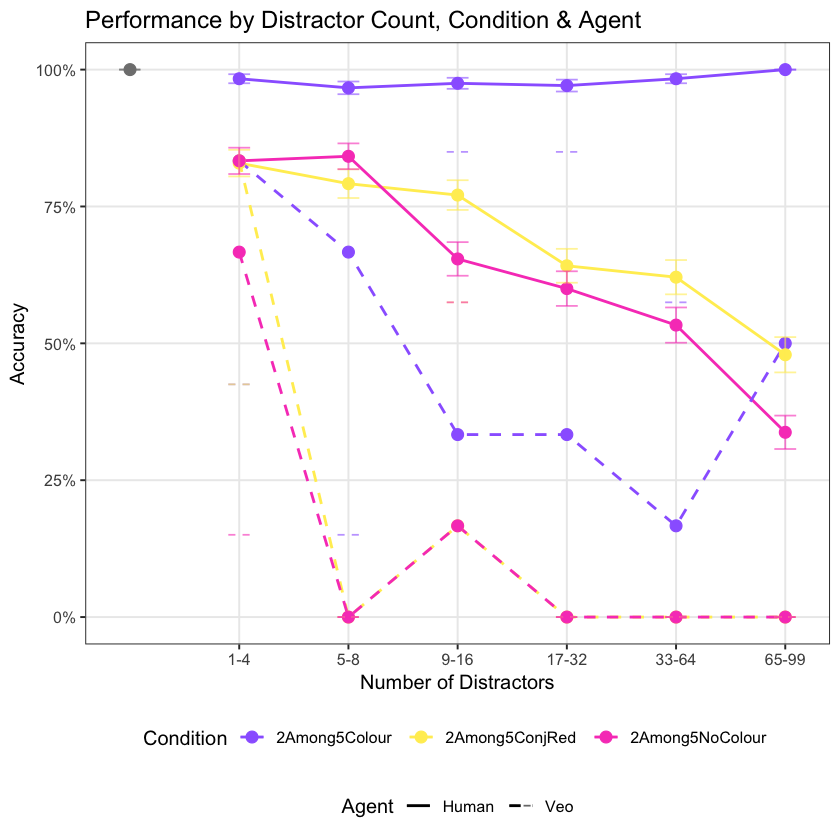

In [182]:
combined_long <- combined_wide %>%
  gather(key = "agent", value = "mean_acc", mean_acc_veo, mean_acc_human) %>%
  mutate(
    se    = ifelse(agent == "mean_acc_veo", se_veo, se_human),
    agent = ifelse(agent == "mean_acc_veo", "Veo", "Human")
  )

print(head(combined_long))
print(table(combined_long$agent, useNA = "ifany"))

condition_colours <- c(
  "2Among5Colour"   = "#9B69FF",
  "2Among5ConjRed"  = "#FFED61",
  "2Among5NoColour" = "#F84AC1"
)

ggplot(combined_long, 
       aes(x        = bin_group, 
           y        = mean_acc,
           colour   = condition,
           linetype = agent,
           group    = interaction(condition, agent))) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = mean_acc - se,
                    ymax = mean_acc + se),
                width = 0.2, alpha = 0.6) +
  scale_colour_manual(values = condition_colours) +
  scale_linetype_manual(values = c("Human" = "solid", "Veo" = "dashed")) +
  scale_x_continuous(
    breaks = 1:6,
    labels = c("1-4", "5-8", "9-16", "17-32", "33-64", "65-99")
  ) +
  scale_y_continuous(
    labels = scales::percent_format(),
    limits = c(0, 1)
  ) +
  labs(
    title    = "Performance by Distractor Count, Condition & Agent",
    x        = "Number of Distractors",
    y        = "Accuracy",
    colour   = "Condition",
    linetype = "Agent"
  ) +
  theme_bw(base_size = 12) +
  theme(
    legend.position  = "bottom",
    legend.box       = "vertical",
    panel.grid.minor = element_blank()
  )

ggsave("fig_Veo_vs_Human.png", width = 8, height = 5, dpi = 150)

## by modelling (agent as a fixed effect)

In [ ]:
humanAndVeo = bind_rows(fulldata %>% 
    select(success, condition, bin_group) %>% 
    mutate(agent = "Veo"),
    humandata %>% select(accuracy, colour_type, bin_group) %>% 
    rename(success = accuracy, condition = colour_type) %>%
    mutate(agent = "Human")
) %>%
  mutate(
    agent     = factor(agent, levels = c("Human", "Veo")),  # Human as reference
    condition = as.character(condition),
    condition = factor(condition),
    bin_group = as.integer(bin_group)
  )
table(humanAndVeo$agent, humanAndVeo$condition, useNA = "ifany")

       
        2Among5Colour 2Among5ConjRed 2Among5NoColour
  Human          1440           1440            1440
  Veo              36             36              36

, ,  = 1

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             5             42              42
  1           241            204             204

, ,  = 2

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0            10             56              44
  1           236            190             202

, ,  = 3

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0            10             60              88
  1           236            186             158

, ,  = 4

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0            11             92             102
  1           235            154             144

, ,  = 5

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             9             97             118
  1           237            149             128

, ,  = 6

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             3            131             165
  1           243            115              81


Model :
success ~ agent * condition * bin_group


there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



,GVIF,Df,GVIF^(1/(2*Df))
agent,10.704665,1,3.271798
condition,36.955691,2,2.465587
bin_group,21.615521,1,4.649249
agent:condition,60.614749,2,2.790259
agent:bin_group,7.780207,1,2.789302
condition:bin_group,185.465837,2,3.690337
agent:condition:bin_group,40.237883,2,2.518598


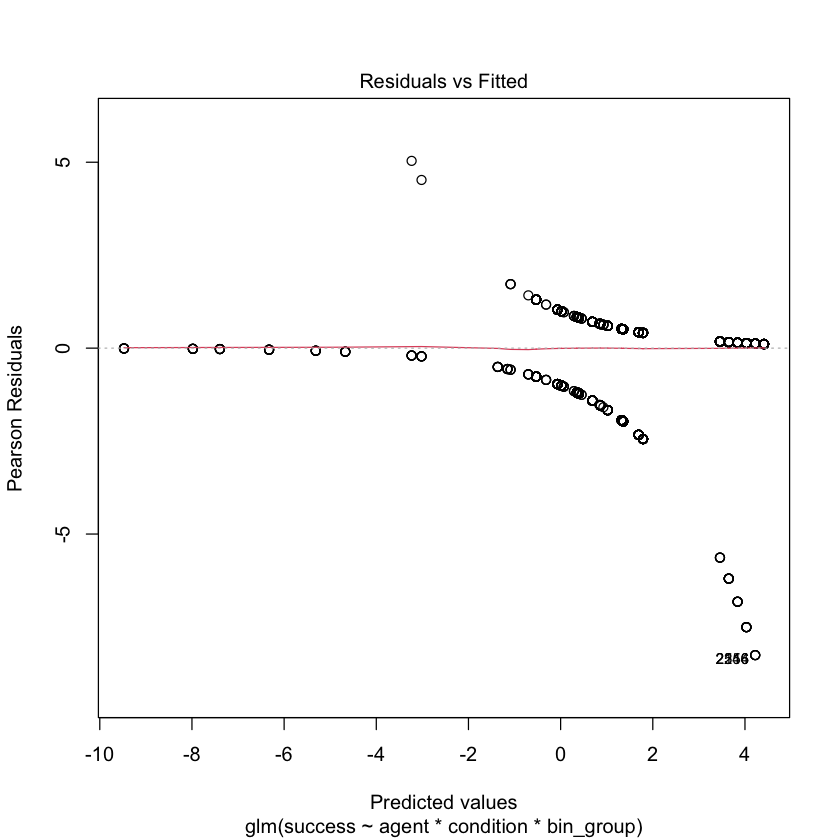

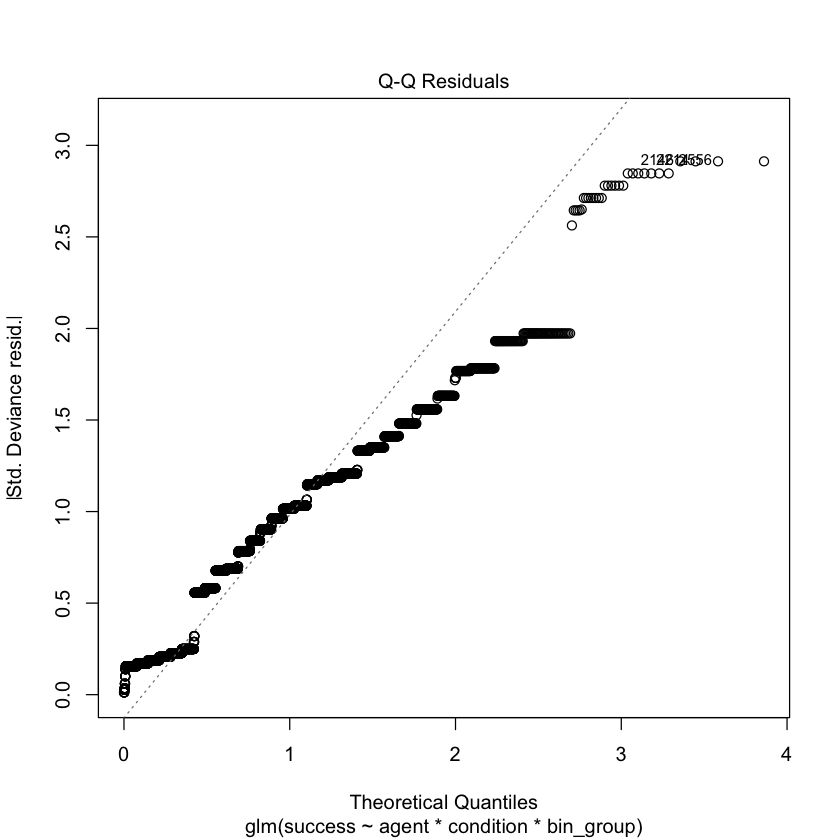

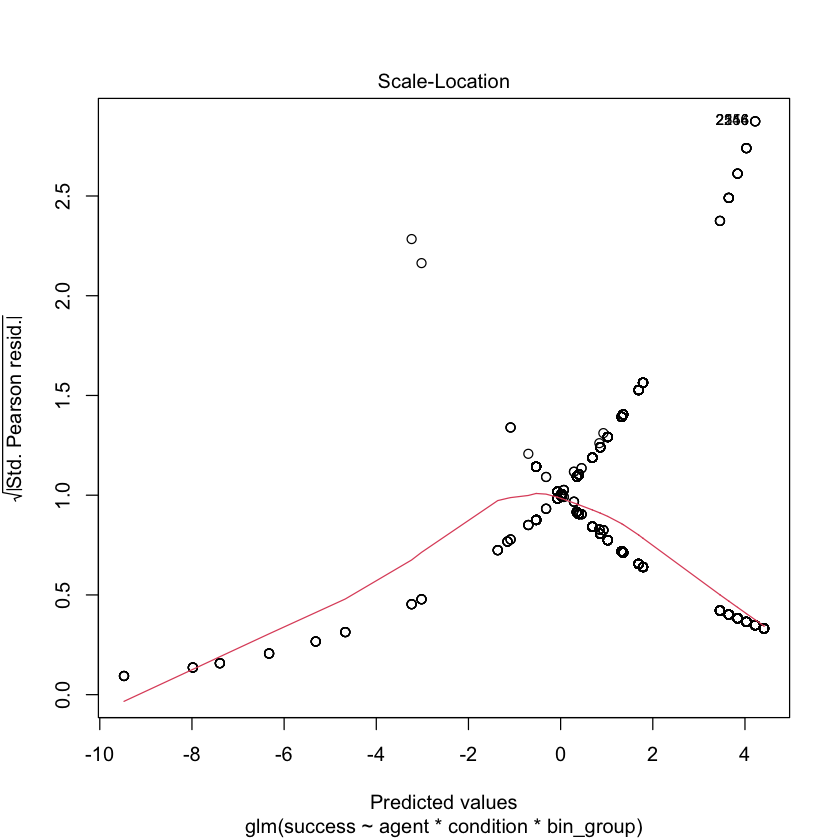

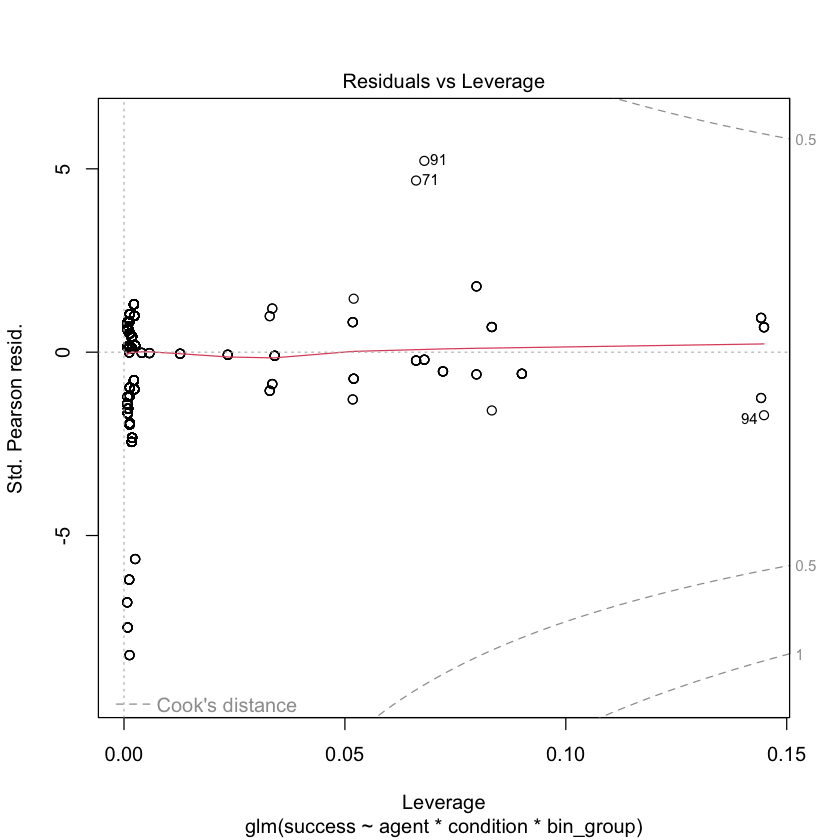

,StudRes,Hat,CookD
,<dbl>,<dbl>,<dbl>
71,2.7533225,0.066107002,0.129238548
75,0.8565307,0.144856717,0.006530171
90,0.8565307,0.144856717,0.006530171
91,2.8972654,0.067975065,0.165410749
2146,-2.9255104,0.001253652,0.007139356
2214,-2.9255104,0.001253652,0.007139356



Call:
glm(formula = success ~ agent * condition * bin_group, family = binomial(link = "logit"), 
    data = humanAndVeo)

Coefficients:
                                            Estimate Std. Error z value
(Intercept)                                   3.2665     0.3864   8.454
agentVeo                                     -2.0413     0.9018  -2.264
condition2Among5ConjRed                      -1.2400     0.4145  -2.991
condition2Among5NoColour                     -1.0147     0.4151  -2.444
bin_group                                     0.1911     0.1135   1.684
agentVeo:condition2Among5ConjRed              3.0225     1.8321   1.650
agentVeo:condition2Among5NoColour             1.7328     1.6598   1.044
agentVeo:bin_group                           -0.5763     0.2420  -2.381
condition2Among5ConjRed:bin_group            -0.5256     0.1190  -4.418
condition2Among5NoColour:bin_group           -0.6550     0.1192  -5.496
agentVeo:condition2Among5ConjRed:bin_group   -1.1695     0.9241  -1.266

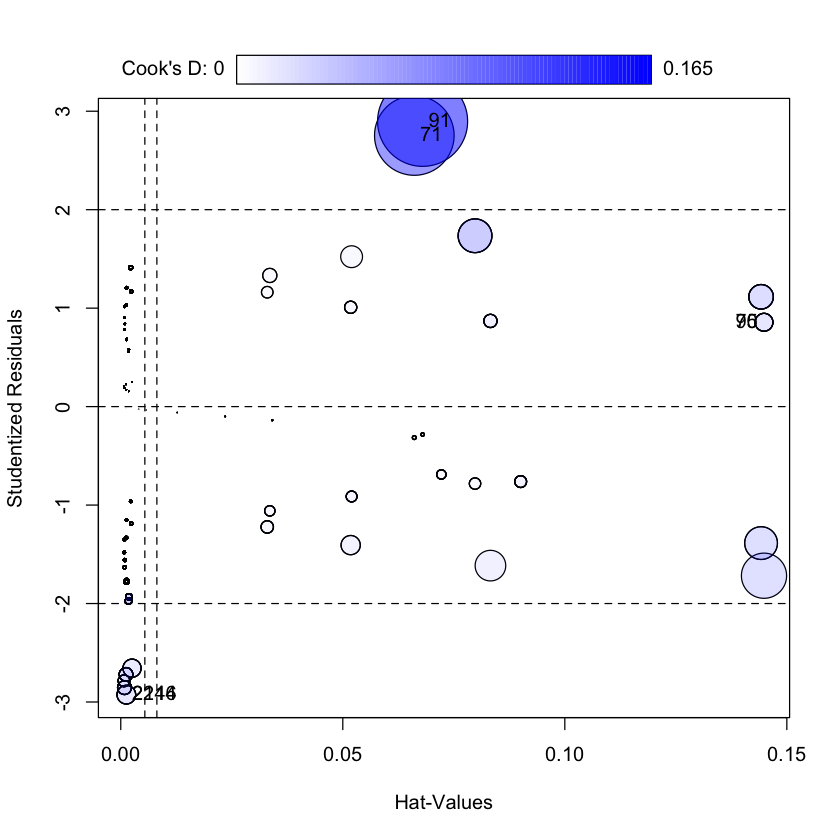

In [ ]:
model_RQ2 = glm(success ~agent*condition*bin_group, data = humanAndVeo, family = binomial(link = "logit"))
# assumption test
# separation (OK)
table(humanAndVeo$success, humanAndVeo$condition, humanAndVeo$bin_group)
# multicollinearity of IVs - VIOLATED ==DISCUSS WHAT TO DO !! 
alias(model_RQ2)
car::vif(model_RQ2)
# linearity of log odds - only for continuous 
# DV is binominal
# uniqueness of observations (for now) assumed
# Sample size at least 10 per term = not given but cannot change (success = 28; fail = 80) <- given DF = 17 issue partially 
# outliers = cooks distance is OK
plot(model_RQ2)
influencePlot(model_RQ2, id=T)
# run model
summary(model_RQ2)
# ? as collapesd the individual condition/ bin varables not ineterpretable? 
# Need to consider how to report 

# hypothesis 3

In [ ]:
# post-hoc tests for bin effects within each condition (Each row tests H₀: slope = 0)
trends_RQ1 <- emtrends(modelRQ1, 
                       specs = ~ condition, 
                       var   = "bin_group")

summary(trends_RQ1, infer = c(TRUE, TRUE))

# more general hierarchical dificulty structure

,condition,bin_group.trend,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2Among5Colour,-0.3852178,0.2137720,Inf,-0.8042032,0.0337677,-1.802003,0.07154498
2,2Among5ConjRed,-2.0803919,0.8911169,Inf,-3.8269490,-0.3338348,-2.334589,0.01956489
3,2Among5NoColour,-1.6539462,0.7700982,Inf,-3.1633109,-0.1445815,-2.147708,0.03173695


### inload data

In [63]:
## prep data for fidelity score analysis
err_cols <- grep("^err_", names(fulldata), value = TRUE)
n_possible <- length(err_cols)
print(colnames(fulldata))
Fidelity_Subset = fulldata  %>% select(success, video_filename, fidelity_score_total, condition, bin_group) %>% mutate(fidelity_relative = fidelity_score_total/n_possible)
Fidelity_Subset$bin_group <- as.factor(Fidelity_Subset$bin_group)
table(Fidelity_Subset$condition, Fidelity_Subset$bin_group)

 [1] "video_filename"          "condition"              
 [3] "bin_x"                   "source_image"           
 [5] "status"                  "image_condition"        
 [7] "shape_type"              "target"                 
 [9] "center_x"                "center_y"               
[11] "size"                    "color"                  
[13] "quadrant"                "row"                    
[15] "column"                  "num_distractors"        
[17] "num_images"              "distractor_color"       
[19] "color_bin_index"         "rotation_angle"         
[21] "bin_group"               "trial_index"            
[23] "condition.1"             "bin_y"                  
[25] "sample"                  "success"                
[27] "failure_type"            "err_no_distractors"     
[29] "err_no_target"           "err_wrong_manip"        
[31] "err_new_target_id"       "err_new_target_unid"    
[33] "err_extra_distractors"   "err_font_change"        
[35] "err_rotation"            

                 
                  1 2 3 4 5 6
  2Among5Colour   6 6 6 6 6 6
  2Among5ConjRed  6 6 6 6 6 6
  2Among5NoColour 6 6 6 6 6 6

### check assumptions


	Shapiro-Wilk normality test

data:  residuals(model_hypothesis3)
W = 0.98891, p-value = 0.5211



	studentized Breusch-Pagan test

data:  model_hypothesis3
BP = 20.383, df = 17, p-value = 0.2551


there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



,GVIF,Df,GVIF^(1/(2*Df))
condition,36,2,2.449490
bin_group,243,5,1.732051
condition:bin_group,3888,10,1.511772


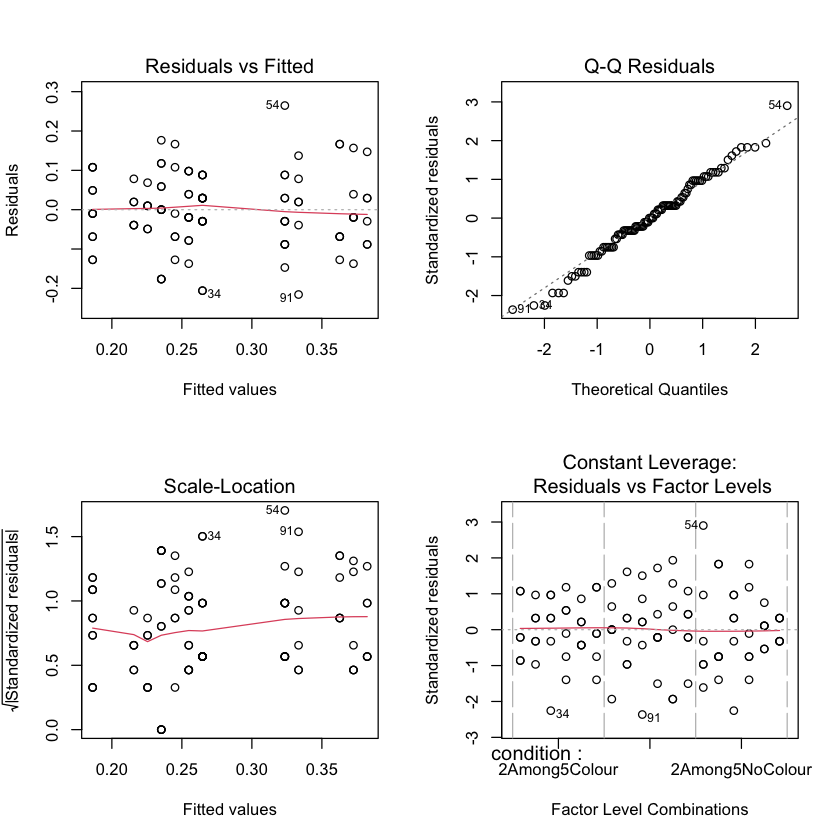

In [ ]:
model_hypothesis3= lm(success ~ condition*bin_group*fidelity_t, data = Fidelity_Subset)
#  Normality 
shapiro.test(residuals(model_hypothesis3)) # OK, not significant = H0 cannot be rejected (H0 being that residuals are normally distributed)
# Homoscedasticity
library(lmtest)
bptest(model_hypothesis3)  # Breusch-Pagan
#  Visual checks
par(mfrow = c(2,2)) # they all look ok 
plot(model_hypothesis3)
# Multicollinearity (for interaction terms) - OK ish condition and interaction are gvif > 10, adjusted for df is < sqrt(10) so likely OKish
library(car)
vif(model_hypothesis3)

### modelling

In [57]:
summary(model_hypothesis3)


Call:
lm(formula = fidelity_relative ~ condition * bin_group, data = Fidelity_Subset)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.21569 -0.05392  0.00000  0.05882  0.26471 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                          0.254902   0.040804   6.247 1.36e-08 ***
condition2Among5ConjRed             -0.019608   0.057705  -0.340   0.7348    
condition2Among5NoColour             0.068627   0.057705   1.189   0.2375    
bin_group2                           0.068627   0.057705   1.189   0.2375    
bin_group3                           0.009804   0.057705   0.170   0.8655    
bin_group4                          -0.068627   0.057705  -1.189   0.2375    
bin_group5                          -0.039216   0.057705  -0.680   0.4985    
bin_group6                          -0.068627   0.057705  -1.189   0.2375    
condition2Among5ConjRed:bin_group2   0.078431   0.081608   0.961   0.3391    
condition2Amon

bin_group = 1:
 contrast  estimate     SE df t.ratio p.value
 linear      0.0686 0.0577 90   1.189  0.2375
 quadratic   0.1078 0.0999 90   1.079  0.2835

bin_group = 2:
 contrast  estimate     SE df t.ratio p.value
 linear      0.0392 0.0577 90   0.680  0.4985
 quadratic  -0.0784 0.0999 90  -0.785  0.4347

bin_group = 3:
 contrast  estimate     SE df t.ratio p.value
 linear      0.0000 0.0577 90   0.000  1.0000
 quadratic  -0.1373 0.0999 90  -1.373  0.1731

bin_group = 4:
 contrast  estimate     SE df t.ratio p.value
 linear      0.0588 0.0577 90   1.019  0.3108
 quadratic  -0.3137 0.0999 90  -3.139  0.0023

bin_group = 5:
 contrast  estimate     SE df t.ratio p.value
 linear      0.0098 0.0577 90   0.170  0.8655
 quadratic  -0.0294 0.0999 90  -0.294  0.7692

bin_group = 6:
 contrast  estimate     SE df t.ratio p.value
 linear      0.0784 0.0577 90   1.359  0.1775
 quadratic  -0.0588 0.0999 90  -0.589  0.5576


bin_group = 1:
 contrast                         estimate     SE df t.ratio p.value
 2Among5Colour - 2Among5ConjRed     0.0196 0.0577 90   0.340  0.9384
 2Among5Colour - 2Among5NoColour   -0.0686 0.0577 90  -1.189  0.4626
 2Among5ConjRed - 2Among5NoColour  -0.0882 0.0577 90  -1.529  0.2823

bin_group = 2:
 contrast                         estimate     SE df t.ratio p.value
 2Among5Colour - 2Among5ConjRed    -0.0588 0.0577 90  -1.019  0.5666
 2Among5Colour - 2Among5NoColour   -0.0392 0.0577 90  -0.680  0.7760
 2Among5ConjRed - 2Among5NoColour   0.0196 0.0577 90   0.340  0.9384

bin_group = 3:
 contrast                         estimate     SE df t.ratio p.value
 2Among5Colour - 2Among5ConjRed    -0.0686 0.0577 90  -1.189  0.4626
 2Among5Colour - 2Among5NoColour    0.0000 0.0577 90   0.000  1.0000
 2Among5ConjRed - 2Among5NoColour   0.0686 0.0577 90   1.189  0.4626

bin_group = 4:
 contrast                         estimate     SE df t.ratio p.value
 2Among5Colour - 2Among5ConjRed    -0.18

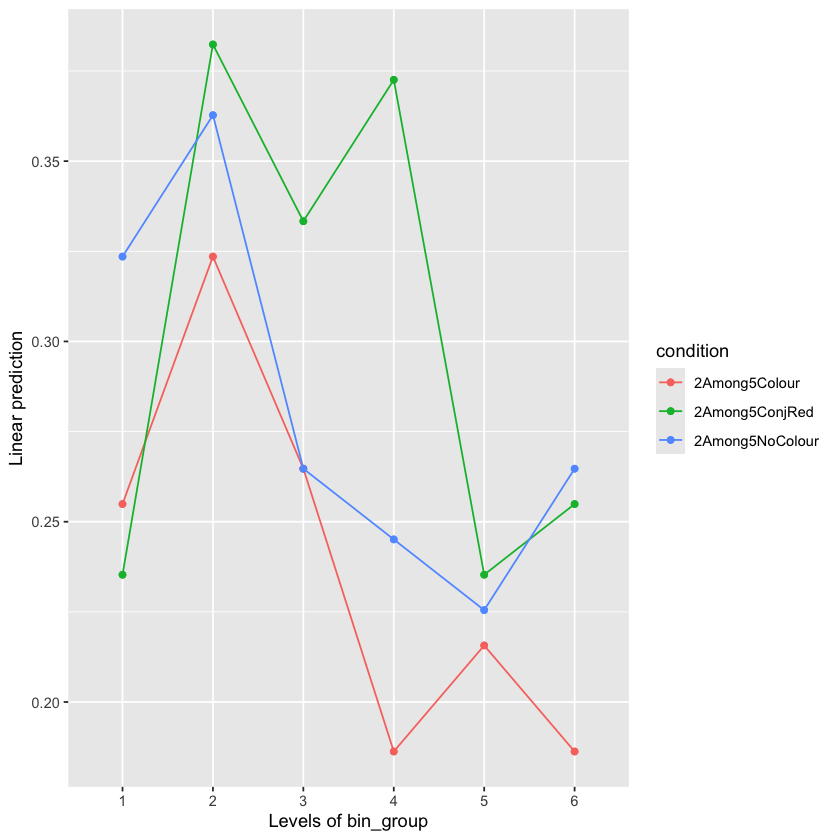

In [60]:
# planned contrests
library(emmeans)
contrasts(Fidelity_Subset$bin_group) <- contr.helmert(6)  # sequential comparisons 1v2, 1+2v3, etc.
contrasts(Fidelity_Subset$condition) <- contr.sum(3)
emm = emmeans(model_hypothesis3, ~ condition | bin_group)
contrast(emm, 'poly')
emmeans(model_hypothesis3, ~ condition | bin_group) |> 
  contrast('pairwise')
emmip(model_hypothesis3, condition ~ bin_group, style = "factor")

### quali during marking suspicious 

In [ ]:
## prep data for fidelity score analysis
Fidelity_Expl = fulldata  %>% select(video_filename, err_circular_motion, err_extra_distractors, condition, bin_group)
Fidelity_Expl$bin_group <- as.factor(Fidelity_Expl$bin_group)
model_hypothesis3_expl= lm(err_circular_motion ~ condition*bin_group, data = Fidelity_Expl)

                 
                  1 2 3 4 5 6
  2Among5Colour   6 6 6 6 6 6
  2Among5ConjRed  6 6 6 6 6 6
  2Among5NoColour 6 6 6 6 6 6